Selected topic for mini-project: \
**Embedding-Based Classifier.**

In [2]:
import re
from typing import List, Callable, Any, Dict
from datasets import load_dataset
from functorch.dim import softmax
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api
import torch
import copy
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

/Users/kirillgorunov/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download dataset **ag_news**:

In [ ]:
dataset = load_dataset("ag_news")

Select train & text:

In [4]:
train_text = dataset["train"]
test_text = dataset["test"]

Sample example:

we have text with new's title and description, and one of four labels

In [5]:
train_text[634]

{'text': 'Dodgers Rally in 8th to Defeat Cubs 8-5 (AP) AP - Adrian Beltre and Shawn Green homered, and Steve Finley hit a go-ahead RBI single in the eighth inning as the Los Angeles Dodgers rallied for an 8-5 victory over the Chicago Cubs on Sunday.',
 'label': 1}

Tokenize all train text:

In [6]:
def tokenize(text: str, pattern: str = None) -> List[str]:
    pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
    tokens = re.findall(pattern, text)
    return tokens

Tokenize train and test tokens

In [7]:
train_tokens = [tokenize(text_sample) for text_sample in list(train_text["text"])]
test_tokens = [tokenize(text_sample) for text_sample in list(test_text["text"])]

And get all tokens for training

In [8]:
all_tokens = train_tokens + test_tokens

In [9]:
VOCAB_SIZE = len(all_tokens)

First, we will train our model on **all corpus of text**:

Create Word2Vec model

In [146]:
model_w2v_locally_train_all_dataset = Word2Vec(
    vector_size=100,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_all_dataset.build_vocab(all_tokens)

Train our Word2Vec model:

In [147]:
model_w2v_locally_train_all_dataset.train(
    corpus_iterable=all_tokens,
    total_examples=len(all_tokens),
    epochs=1,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(4249263, 5154488)

Also, we train word2vec on small data (30% of dataset)

In [189]:
percent_30_dataset = all_tokens[np.random.choice(int(len(all_tokens) * 0.30))]

In [ ]:
model_w2v_locally_train_30_percent = Word2Vec(
    vector_size=100,
    window=4,
    min_count=1,
    sg=1,
    epochs=2000,
    seed=42,
    workers=12,
    negative=6,
)
model_w2v_locally_train_30_percent.build_vocab(percent_30_dataset)
model_w2v_locally_train_30_percent.train(
    corpus_iterable=percent_30_dataset,
    total_examples=len(percent_30_dataset),
    epochs=1,
)

And last model is pretrained word2vec

In [ ]:
# path = api.load("word2vec-google-news-300", return_path=True)
# print('download to:', path)
path = "/Users/kirillgorunov/gensim-data/word2vec-google-news-300"

In [ ]:
# !gzip -d path

In [ ]:
google_w2v_model_pretrained = KeyedVectors.load_word2vec_format(f'{path}/word2vec-google-news-300', binary=True)

Now we have all 3 type of word2vec models and next part is prepare dataset

We know that existing 2 types of create "embedding" of sentence from words embedding - pooling and concatenation

In this word we will use pooling

In [ ]:
def pool_sentence(sentense_raw: str, w2v_model, embedding_dim=100) -> np.ndarray[Any]:
    sentense_tokens: List[str] = tokenize(sentense_raw)
    sentense = [w2v_model.wv[token] if hasattr(w2v_model, "wv") else w2v_model[token] if token in w2v_model else np.zeros(embedding_dim) for token in sentense_tokens]
    # pool
    if not sentense:
        return np.zeros(embedding_dim)
    result = np.array(sentense).mean(axis=0)
    return result

Example of our function:

Sentence -> tokenize each word -> take mean of all vectors

In [190]:
pool_sentence(train_text["text"][0], w2v_model=google_w2v_model_pretrained)

NameError: name 'google_w2v_model_pretrained' is not defined

And prepare data:

In [ ]:
# full
X_locally_full_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_all_dataset) for sample in train_text["text"]], dtype=torch.float32)
y_locally_full_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

In [ ]:
X_test_locally_full_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_all_dataset) for sample in test_text["text"]], dtype=torch.float32)
y_test_locally_full_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

In [ ]:
# 30 % dataset
X_locally_30_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_30_percent) for sample in train_text["text"]], dtype=torch.float32)
y_locally_30_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

In [ ]:
X_test_locally_30_ag_news = torch.tensor([pool_sentence(sample, model_w2v_locally_train_30_percent) for sample in test_text["text"]], dtype=torch.float32)
y_test_locally_30_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

In [ ]:
# pretrained
X_pretrained_ag_news = torch.tensor([pool_sentence(sample, google_w2v_model_pretrained, 300) for sample in train_text["text"]], dtype=torch.float32)
y_pretrained_ag_news = torch.tensor(train_text["label"], dtype=torch.long)

In [ ]:
X_test_pretrained_ag_news = torch.tensor([pool_sentence(sample, google_w2v_model_pretrained, 300) for sample in test_text ["text"]], dtype=torch.float32)
y_test_pretrained_ag_news = torch.tensor(test_text["label"], dtype=torch.long)

After training word2vec we need to create Tenser Object to Feed our future nn model

We know that existing 2 types of create "embedding" of sentence from words embedding - pooling and concatenation

In [14]:
X = torch.tensor([pool_sentence(sample, model) for sample in train_text["text"]], dtype=torch.float32)
y = torch.tensor(train_text["label"], dtype=torch.long)

/var/folders/y5/f3lzxvn542d8prr4rnvmc1dw0000gn/T/ipykernel_54671/2115681574.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X = torch.tensor([pool_sentence(sample, model) for sample in train_text["text"]], dtype=torch.float32)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [169]:
class FNNModel(torch.nn.Module):
    def __init__(self, embedding_dim=100, hidden_dim_1=200, hidden_dim_2=100, num_classes=4):
        super().__init__()

        self.fc1 = torch.nn.Linear(embedding_dim, hidden_dim_1)
        self.fc2 = torch.nn.Linear(hidden_dim_1, hidden_dim_2)
        self.output = torch.nn.Linear(hidden_dim_2, num_classes)
        self.relu = torch.nn.ReLU()

    def forward(self, input):
        o1 = self.relu(self.fc1(input))
        o2 = self.relu(self.fc2(o1))
        result = self.output(o2)
        return result


In [17]:
def accuracy(y_pred, y):
    # multiclasses
    classes = y_pred.argmax(dim=1)
    return (classes == y).float().mean()

def train(model_nn: torch.nn.Module,
          loss: Callable,
          opt: Callable,
          X_train: torch.Tensor,
          y_train: torch.Tensor,
          X_valid: torch.Tensor,
          y_valid: torch.Tensor,
          lr: float,
          batch_size: int,
          epochs: int):

    loss_history: List[float] = list()
    batch_count = int(len(X_train) / batch_size)
    best_res_accuracy = -1.0
    best_weights = None

    optimizer = opt(model_nn.parameters(), lr=lr)

    count_accuracy_same = 0
    max_count_accuracy_same = 30

    for epoch in range(epochs):
        model_nn.train()
        for batch_num in range(batch_count):
            batch_start = batch_num * batch_size

            X_train_batch = X_train[batch_start:batch_start + batch_size]
            y_train_batch = y_train[batch_start:batch_start + batch_size]

            y_pred = model_nn(X_train_batch)
            loss_res = loss(y_pred, y_train_batch)

            optimizer.zero_grad()
            loss_res.backward()

            optimizer.step()

            loss_history.append(float(loss_res))

        model_nn.eval()
        y_pred = model_nn(X_valid)

        new_accuracy = accuracy(y_pred, y_valid)
        print(f"Epoch {epoch + 1}/{epochs}, loss: {float(loss_res)}, accuracy: {float(new_accuracy)}")
        if new_accuracy > best_res_accuracy:
            best_res_accuracy = new_accuracy
            best_weights = copy.deepcopy(model_nn.state_dict())
            count_accuracy_same = 0
        else:
            count_accuracy_same += 1

        if max_count_accuracy_same == count_accuracy_same:
            print(f"early stopped on epoch: {epoch}. best accuracy: {best_res_accuracy}")
            break

    print(f"Total epoch: {epoch}. best accuracy: {best_res_accuracy}")
    model_nn.load_state_dict(best_weights)

    return loss_history, best_res_accuracy

In [18]:
nn_model = FNNModel()

loss_history, best_accuracy = train(
    model_nn=nn_model,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_val,
    y_valid=y_val,
    lr=0.1,
    batch_size=64,
    epochs=100,
)



/var/folders/y5/f3lzxvn542d8prr4rnvmc1dw0000gn/T/ipykernel_54671/3694026848.py:43: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  loss_history.append(float(loss_res))


Epoch 1/100, loss: 0.2455771565437317, accuracy: 0.8852916955947876
Epoch 2/100, loss: 0.4050082564353943, accuracy: 0.8809999823570251
Epoch 3/100, loss: 0.30374836921691895, accuracy: 0.8799583315849304
Epoch 4/100, loss: 0.30900636315345764, accuracy: 0.8798333406448364
Epoch 5/100, loss: 0.28521475195884705, accuracy: 0.8865416646003723
Epoch 6/100, loss: 0.3155996799468994, accuracy: 0.8706666827201843
Epoch 7/100, loss: 0.32029467821121216, accuracy: 0.8723333477973938
Epoch 8/100, loss: 0.2925831973552704, accuracy: 0.8855416774749756
Epoch 9/100, loss: 0.30466094613075256, accuracy: 0.8796250224113464
Epoch 10/100, loss: 0.2637571096420288, accuracy: 0.890291690826416
Epoch 11/100, loss: 0.29938453435897827, accuracy: 0.8809999823570251
Epoch 12/100, loss: 0.29327595233917236, accuracy: 0.8799583315849304
Epoch 13/100, loss: 0.27409976720809937, accuracy: 0.890250027179718
Epoch 14/100, loss: 0.27750906348228455, accuracy: 0.8806666731834412
Epoch 15/100, loss: 0.35263651609420

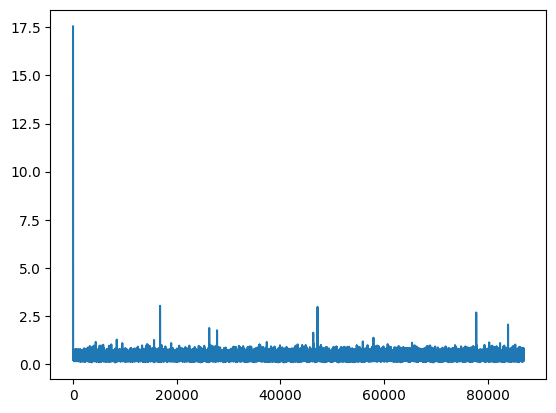

In [19]:
plt.plot(loss_history[4:])

In [20]:
dataset["test"][2]

{'text': 'Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.',
 'label': 3}

In [21]:
# text = pool_sentence(dataset["test"]["text"][2], w2v_model=model)
text = pool_sentence("Arsenal latest: joins two players in pulling out of international duty", w2v_model=model)

In [22]:
test_x = torch.tensor(text, dtype=torch.float32).unsqueeze(0)

In [23]:
test_x

tensor([[ 2.8484e-01,  8.5604e-03, -2.4354e-01,  2.2415e-01,  1.2095e-01,
          8.2481e-02, -3.4805e-02,  1.5169e-01, -4.1178e-01, -4.8777e-03,
         -3.1219e-01,  2.7249e-01,  1.5626e-01,  3.6544e-01, -8.6076e-02,
         -1.0726e-01,  2.0947e-01, -2.9242e-01,  2.2973e-02,  1.6703e-01,
          1.7629e-01,  1.1089e-01, -8.3178e-05,  6.4181e-02,  3.0792e-01,
         -1.8098e-01, -1.8512e-02,  2.1861e-01, -2.0774e-01, -8.3909e-02,
          4.5268e-02,  1.4594e-01,  7.4441e-02,  2.5305e-02, -3.0592e-02,
          4.6196e-02,  6.7967e-02, -3.5700e-01, -1.0202e-01,  3.6372e-02,
          2.0526e-04,  1.8198e-01,  6.8018e-02, -1.8342e-01,  1.6061e-01,
          9.9638e-02,  1.4847e-01,  1.0358e-01,  4.6275e-01, -1.1981e-01,
         -8.4949e-02, -1.9956e-01, -2.5118e-02,  7.1663e-02,  3.2777e-01,
         -1.3161e-01,  9.7528e-02,  2.1134e-01, -2.3002e-01,  2.8156e-01,
          6.0564e-02,  1.0165e-02, -1.2578e-01,  1.0813e-01,  1.8636e-02,
          2.3526e-01,  6.0585e-02,  7.

In [24]:
nn_model.eval()
with torch.no_grad():
    y_pred = nn_model(test_x)
    # y_pred = torch.argmax(y_pred, dim=1)
    torch.softmax(y_pred, dim=1)
    print(np.round(torch.softmax(y_pred, dim=1, dtype=torch.float32), 2),)
# model(text)

tensor([[0.0200, 0.9600, 0.0100, 0.0100]])


In [25]:
model.wv["Wildfires"]

array([ 1.88234195e-01, -4.21038896e-01, -4.17021334e-01, -2.46328041e-01,
       -2.94214100e-01, -4.72373098e-01, -2.38366619e-01, -1.28378272e-01,
       -4.28516418e-01, -4.35669154e-01, -1.22838771e+00,  1.20062500e-01,
        1.14933920e+00,  1.24034512e+00, -4.17412162e-01,  3.81246209e-01,
        8.46160412e-01,  2.43800089e-01, -1.55982658e-01,  6.61083877e-01,
       -6.48419619e-01, -1.37939677e-01, -3.68911684e-01, -4.52001065e-01,
       -2.48636857e-01, -9.54978347e-01, -1.18304558e-01,  1.02910864e+00,
       -8.39756668e-01,  3.42914790e-01, -8.46305788e-01, -7.47357830e-02,
        6.17813133e-02, -7.68878818e-01,  3.92734408e-02, -5.58020711e-01,
        1.21101759e-01, -4.16611701e-01,  5.87271988e-01, -5.45198582e-02,
       -4.87312466e-01, -1.82898194e-01,  4.52065438e-01, -1.18175387e-01,
       -3.90134186e-01,  4.96361762e-01, -3.10751479e-02,  8.06401432e-01,
        1.15390527e+00,  2.21314758e-01, -9.82191741e-01, -9.31170166e-01,
        4.73703146e-01, -

In [162]:
test_text["text"][0]

"Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul."

In [188]:
X_test = torch.tensor([pool_sentence(sample, model) for sample in test_text["text"]], dtype=torch.float32)
y_test = torch.tensor(test_text["label"], dtype=torch.long)

In [192]:
nn_model.eval()
with torch.no_grad():
    y_pred = nn_model(X_test)
    # y_pred = torch.argmax(y_pred, dim=1)
    print(accuracy(y_pred, y_test))
# model(text)

tensor(0.8876)


In [129]:
!gzip -d /Users/kirillgorunov/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz

In [131]:
!ls /Users/kirillgorunov/gensim-data/word2vec-google-news-300/word2vec-google-news-300

/Users/kirillgorunov/gensim-data/word2vec-google-news-300/word2vec-google-news-300


In [128]:
Googlemodel = Word2Vec.load("/Users/kirillgorunov/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz")

UnpicklingError: invalid load key, '3'.

In [133]:
from gensim.models import KeyedVectors

Googlemodel = KeyedVectors.load_word2vec_format('/Users/kirillgorunov/gensim-data/word2vec-google-news-300/word2vec-google-news-300', binary=True)

In [142]:
len(Googlemodel["google"])

300

In [163]:
X = torch.tensor([pool_sentence(sample, Googlemodel, 300) for sample in train_text["text"]], dtype=torch.float32)
y = torch.tensor(train_text["label"], dtype=torch.long)

In [166]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [171]:
nn_model_google = FNNModel(embedding_dim=300, hidden_dim_1=200, hidden_dim_2=100, num_classes=4)

loss_history, best_accuracy = train(
    model_nn=nn_model_google,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_val,
    y_valid=y_val,
    lr=0.01,
    batch_size=64,
    epochs=100,
)

Epoch 1/100, loss: 0.25856244564056396, accuracy: 0.8961666822433472
Epoch 2/100, loss: 0.2261667549610138, accuracy: 0.9103333353996277
Epoch 3/100, loss: 0.18318164348602295, accuracy: 0.9133333563804626
Epoch 4/100, loss: 0.1589636206626892, accuracy: 0.9148333072662354
Epoch 5/100, loss: 0.15499967336654663, accuracy: 0.9135416746139526
Epoch 6/100, loss: 0.15133193135261536, accuracy: 0.9150416851043701
Epoch 7/100, loss: 0.11765280365943909, accuracy: 0.918833315372467
Epoch 8/100, loss: 0.138457253575325, accuracy: 0.9153749942779541
Epoch 9/100, loss: 0.12383052706718445, accuracy: 0.9159166812896729
Epoch 10/100, loss: 0.10619481652975082, accuracy: 0.9154166579246521
Epoch 11/100, loss: 0.09058935940265656, accuracy: 0.9143750071525574
Epoch 12/100, loss: 0.1743873506784439, accuracy: 0.9129166603088379
Epoch 13/100, loss: 0.08200471848249435, accuracy: 0.9097499847412109
Epoch 14/100, loss: 0.12142620235681534, accuracy: 0.9126666784286499
Epoch 15/100, loss: 0.0798453167080

In [172]:
X_test = torch.tensor([pool_sentence(sample, Googlemodel, 300)for sample in test_text["text"]], dtype=torch.float32)
y_test = torch.tensor(test_text["label"], dtype=torch.long)

In [173]:
nn_model_google.eval()
with torch.no_grad():
    y_pred = nn_model_google(X_test)
    # y_pred = torch.argmax(y_pred, dim=1)
    print(accuracy(y_pred, y_test))

tensor(0.9151)


In [184]:
from sklearn.metrics import f1_score
with torch.no_grad():
    y_pred = nn_model_google(X_test)
    classes = y_pred.argmax(dim=1)
    print(f1_score(y_true=y_test, y_pred=classes, average=None))

[0.91587774 0.972706   0.88025546 0.89122627]


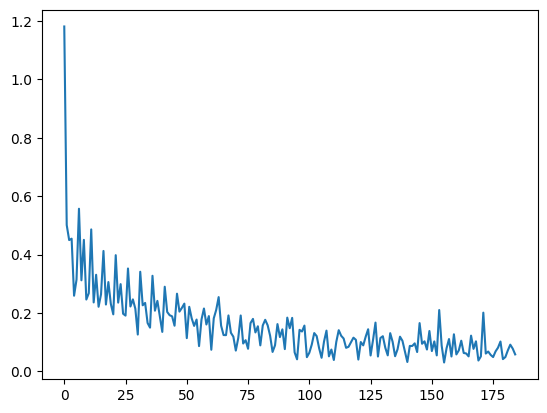

In [179]:
plt.plot(loss_history[4:-1:300])

In [127]:
# import gensim.downloader as api
# path = api.load("word2vec-google-news-300", return_path=True)
# print(path)

In [165]:
class FNNWithEmbedding(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=100)
        self.fc1 = torch.nn.Linear(100, 200)
        self.fc2 = torch.nn.Linear(200, 100)
        self.output = torch.nn.Linear(100, 4)
        self.relu = torch.nn.ReLU()

    def forward(self, input):
        input_embedding = self.embedding(input)
        pooled = input_embedding.mean(dim=1)
        o1 = self.relu(self.fc1(pooled))
        o2 = self.relu(self.fc2(o1))
        result = self.output(o2)
        return result

In [64]:
all_tokens_vector = [token for sentence in all_tokens for token in sentence]

In [65]:
vocab = {token: token_id for token_id, token in enumerate(set(all_tokens_vector))}
vocab["<UNK>"] = 0

In [66]:
def text_to_ids(text: str, vocab: Dict[str, int]):
    matrix_result = np.zeros(100)
    ids = [vocab.get(token, 0) for token in tokenize(text)]
    ids = ids[:100]
    matrix_result[:len(ids)] = ids
    return matrix_result

In [60]:
text_to_ids(train_text["text"][0], vocab)

array([100858.,  12634.,   9874.,  81694.,  24901.,  60769., 100537.,
         5423.,  62890.,  15990.,  15990.,  89418., 100858.,   1073.,
        30360.,  61094.,  31900.,  81409.,  85832.,  68435.,  19787.,
        53974.,   9874.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,     

In [47]:
X = torch.tensor([text_to_ids(sample, vocab) for sample in train_text["text"]], dtype=torch.long)
y = torch.tensor(train_text["label"], dtype=torch.long)

In [61]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
nn_model_embedding = FNNWithEmbedding()

loss_history, best_accuracy = train(
    model_nn=nn_model_embedding,
    loss=torch.nn.CrossEntropyLoss(),
    opt=torch.optim.Adam,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_val,
    y_valid=y_val,
    lr=0.001,
    batch_size=64,
    epochs=2,
)

Epoch 1/2, loss: 0.26229754090309143, accuracy: 0.875124990940094
Epoch 2/2, loss: 0.15814881026744843, accuracy: 0.8919583559036255
Total epoch: 1. best accuracy: 0.8919583559036255


In [117]:
nn_model_embedding.fc1.weight

Parameter containing:
tensor([[ 3.9483e-01, -4.1907e-01, -4.3981e-01,  ..., -8.4341e-01,
          3.4436e-01,  3.8695e-01],
        [ 1.0630e+00,  3.8205e-02,  5.4395e-01,  ..., -9.7532e-01,
         -7.5978e-02, -3.0901e-01],
        [ 1.1405e+00, -6.8940e-01, -7.3892e-01,  ...,  4.6332e-02,
         -4.8863e-04,  1.2130e+00],
        ...,
        [ 4.1967e+00, -1.6199e+00, -2.0838e+00,  ...,  8.1401e-01,
          2.4001e-01,  5.7428e-02],
        [ 3.6266e+00, -1.9135e+00, -2.1834e+00,  ...,  2.2789e+00,
          3.6341e-01,  1.0084e-02],
        [ 2.0307e+00, -3.2695e+00, -4.2268e+00,  ..., -1.6859e+00,
          8.0470e-01,  2.7394e+00]], requires_grad=True)

In [70]:
x_test = torch.tensor(text_to_ids(train_text["text"][0], vocab), dtype=torch.long)
# nn_model_embedding(x_test)

In [120]:
for name, param in nn_model_embedding.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())

embedding.weight 0.6926902532577515
fc1.weight 1.438224196434021
fc1.bias 0.2786840498447418
fc2.weight 0.1610797792673111
fc2.bias 0.07215234637260437
output.weight 0.2638908326625824
output.bias 0.05889728292822838
